## Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import Dependencies

In [20]:
import tensorflow
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img

In [7]:
# image load
img = image.load_img('/content/drive/MyDrive/Cat/cat.9259.jpg', target_size=(224, 224))

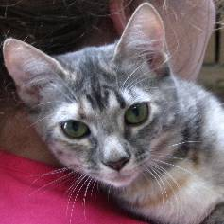

In [8]:
#Show image. Another process also have that is openCV 'imshow()' function.. In this way image is saved as numpy array
img

In [9]:
type(img)    # store as image Not numpy_array

PIL.Image.Image

### Data Augmentation

In [10]:
Imagedatagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

As we store image as image, before any operations we convert it into Numpy array

In [13]:
img = image.img_to_array(img) # Convert PIL Image to NumPy array
img.shape

(224, 224, 3)

Define Batch

Since we have only one image, defining a batch is not necessary.

In [14]:
input_batch = img.reshape(1,224,224,3)

In [15]:
input_batch

array([[[[ 33.,  25.,  23.],
         [ 30.,  22.,  20.],
         [ 32.,  24.,  22.],
         ...,
         [124., 114., 102.],
         [127., 117., 105.],
         [119., 111., 100.]],

        [[ 32.,  24.,  22.],
         [ 28.,  20.,  18.],
         [ 30.,  22.,  20.],
         ...,
         [117., 107.,  95.],
         [112., 102.,  90.],
         [104.,  96.,  85.]],

        [[ 26.,  18.,  16.],
         [ 22.,  14.,  12.],
         [ 23.,  15.,  13.],
         ...,
         [103.,  93.,  83.],
         [ 95.,  85.,  75.],
         [ 93.,  84.,  75.]],

        ...,

        [[201.,  59., 131.],
         [204.,  62., 134.],
         [207.,  65., 137.],
         ...,
         [ 70.,  65.,  69.],
         [ 76.,  71.,  75.],
         [ 84.,  82.,  87.]],

        [[205.,  63., 135.],
         [206.,  64., 136.],
         [206.,  64., 136.],
         ...,
         [ 67.,  62.,  68.],
         [ 76.,  74.,  79.],
         [ 96.,  94.,  99.]],

        [[209.,  67., 141.],
       

Saving process for Local machine

In [17]:
import os

i = 0
output_dir = 'Augmentated Cats Images'

# Create the directory if it does not exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for output in Imagedatagen.flow(input_batch, batch_size=1, save_to_dir=output_dir):
  i = i+1

  if i == 10:
    break

In [21]:
import shutil
import os
import numpy as np


# Define destination folder directly in Drive
destination_folder = '/content/drive/MyDrive/Augmented_Cats_Images'

# Create folder if not exists
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

# Initialize counter
i = 0


for output_batch in Imagedatagen.flow(input_batch, batch_size=1):
  i = i+1

  # Get the single image array from the batch
  augmented_image_array = output_batch[0]

  # Convert augmented image array to PIL Image
  augmented_image_pil = array_to_img(augmented_image_array)

  # Manually set Augmentated image name
  filename = f"cat_{i:02d}.jpg"

  # Save directly to Drive
  augmented_image_pil.save(os.path.join(destination_folder, filename))

  if i == 10:
    break